# GM6208-150T terminal resistance — bench duty-sequence stall capture

Computes the motor's terminal (line-to-line) resistance from the firmware's
`PCS_BENCH_DUTY_SEQ` stall schedule, for the SIL plant's `MotorParams.r_ohm`
(per-phase = half the terminal value).

**Input:** `motor_stall_various_duty.csv` (this directory) — `tools/serial_capture.py`
log of the bench telemetry set, everything at the 2 ms tier: `bench_duty`,
`motor_angle`, `vbus_v`, `phase_{u,v,w}_v`, `phase_{u,v,w}_i`. The rotor is
held while the button-triggered schedule steps duty 0 → 0.6 → 0.

**Method:** segments come straight from `bench_duty` (the commanded level),
trimmed 300 ms after each transition. Zero-duty dwells calibrate the
current-sense offsets. The board's shunts are **low-side**, so a leg's shunt
sees winding current only while its low-side path conducts: the tied-low leg
reads the true current full-time, the PWM'd leg reads ≈ `(1−duty)·I` under
the asynchronous ADC sampling — the tied-low leg is therefore the current
reference and the `(1−duty)` ratio on the other leg is a per-segment sanity
check. `V_LL` is the mean vsense difference (PWM leg − tied-low leg); the
2 ms vsense samples swing with the PWM, so the segment mean recovers the
averaged terminal voltage. Stall ⇒ zero BEMF ⇒ `R_LL = V_LL / I`, fitted
across segments. Run with the repo venv kernel (`.venv`).

In [2]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CSV = Path("motor_stall_various_duty.csv")
PHASES = ["U", "V", "W"]
TRIM_SAMPLES = 150   # 300 ms settle after each duty transition (2 ms cadence)

raw = defaultdict(list)
with open(CSV) as f:
    for row in csv.DictReader(f):
        raw[row["signalName"].split("/")[-1]].append((int(row["t"]), float(row["value"])))
sig = {name: (np.array([t for t, _ in v]) * 1e-3, np.array([x for _, x in v]))
       for name, v in sorted(raw.items())}
t0 = min(t[0] for t, _ in sig.values())
sig = {name: (t - t0, v) for name, (t, v) in sig.items()}

# One aligned sample grid: every signal shares the 2 ms cadence; truncate to
# the shortest so indices line up.
n = min(len(v) for _, v in sig.values())
tb = sig["bench_duty"][0][:n]
duty = sig["bench_duty"][1][:n]
I_raw = np.stack([sig[f"phase_{p.lower()}_i"][1][:n] for p in PHASES])
V = np.stack([sig[f"phase_{p.lower()}_v"][1][:n] for p in PHASES])
vbus = sig["vbus_v"][1][:n]
angle = sig["motor_angle"][1][:n]

print(f"{n} aligned samples over {tb[-1] - tb[0]:.1f} s")
print(f"duty levels: {sorted(set(np.round(duty, 3)))}")
print(f"vbus {vbus.mean():.2f} V (sd {vbus.std() * 1e3:.0f} mV); "
      f"stall creep {angle.max() - angle.min():.2f} deg mech")

21998 aligned samples over 44.0 s
duty levels: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.45), np.float64(0.6)]
vbus 19.57 V (sd 11 mV); stall creep 3.56 deg mech


## Raw capture

The commanded staircase, the phase currents' response (note the PWM'd leg
reading below the tied-low leg — the low-side-shunt visibility effect), and
the stall quality.

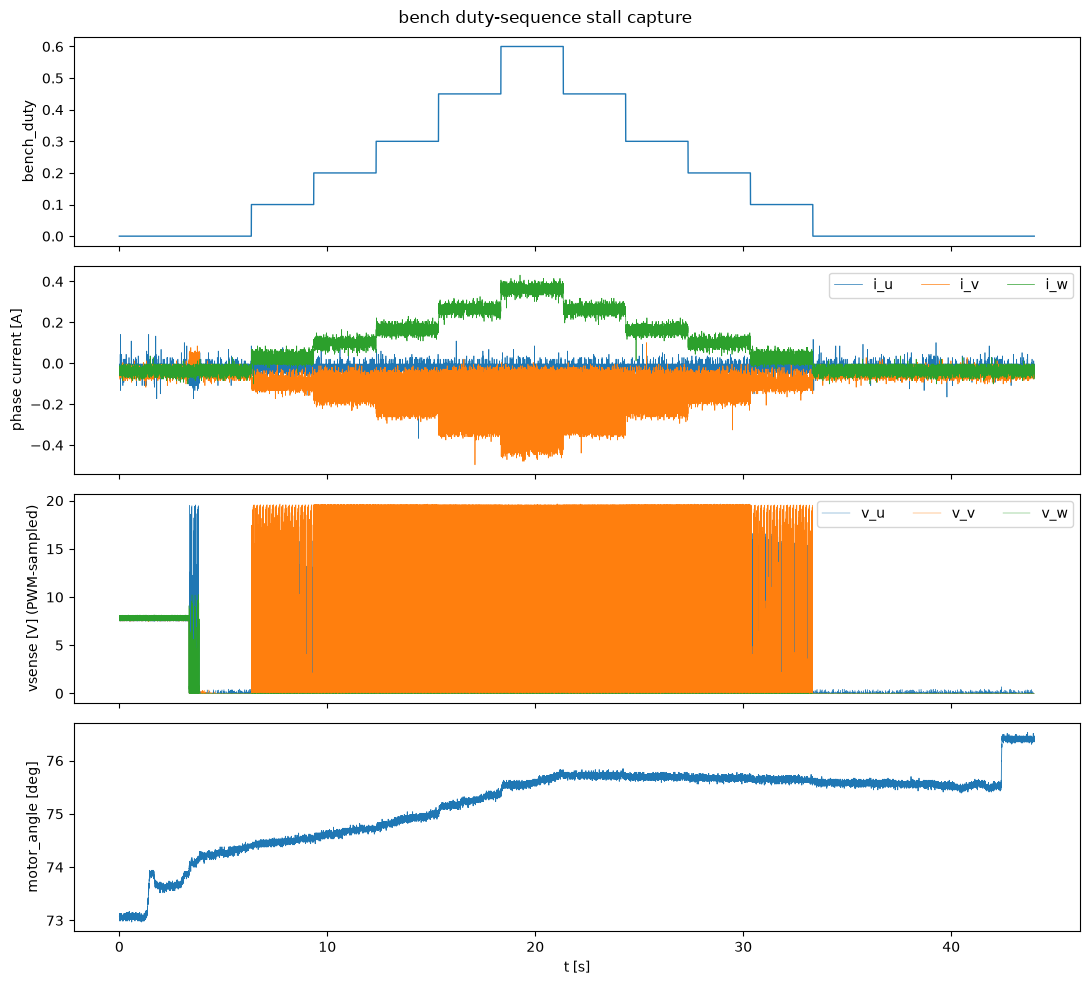

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
axes[0].plot(tb, duty, lw=1.0)
axes[0].set_ylabel("bench_duty")
for k, p in enumerate(PHASES):
    axes[1].plot(tb, I_raw[k], lw=0.5, label=f"i_{p.lower()}")
axes[1].set_ylabel("phase current [A]")
axes[1].legend(ncol=3)
for k, p in enumerate(PHASES):
    axes[2].plot(tb, V[k], lw=0.3, label=f"v_{p.lower()}")
axes[2].set_ylabel("vsense [V] (PWM-sampled)")
axes[2].legend(ncol=3)
axes[3].plot(tb, angle, lw=0.6)
axes[3].set_ylabel("motor_angle [deg]")
axes[3].set_xlabel("t [s]")
fig.suptitle("bench duty-sequence stall capture")
fig.tight_layout()

## Current-sense offsets from the zero-duty dwells

The schedule's leading/trailing zero-duty holds carry no winding current, so
each channel's mean there is its sensor offset — subtracted from everything
downstream.

In [4]:
zero = (duty == 0.0) & (tb > 1.0)
offsets = I_raw[:, zero].mean(axis=1)
I = I_raw - offsets[:, None]
for p, o, s in zip(PHASES, offsets, I_raw[:, zero].std(axis=1)):
    print(f"phase {p}: offset {o * 1e3:+6.1f} mA  (noise sd {s * 1e3:.1f} mA, "
          f"n={zero.sum()})")

phase U: offset  -22.2 mA  (noise sd 20.7 mA, n=7997)
phase V: offset  -45.0 mA  (noise sd 20.2 mA, n=7997)
phase W: offset  -35.3 mA  (noise sd 16.7 mA, n=7997)


## Per-level extraction

Per duty level (transitions trimmed): the PWM'd leg is the one with the
highest mean terminal voltage; the tied-low conducting partner is the
larger-|current| remaining phase. `I` comes from the tied-low leg (full-time
shunt visibility); the `(1−d)·I` column against the PWM leg's reading checks
the visibility model; `V_LL` is the mean vsense difference.

In [5]:
levels = sorted(set(np.round(duty[duty > 0.0], 3)))
rows = []
for lvl in levels:
    m = np.round(duty, 3) == lvl
    keep = m.copy()
    for e in np.flatnonzero(np.diff(np.concatenate([[0], m.astype(int)])) == 1):
        keep[e:e + TRIM_SAMPLES] = False
    vm = V[:, keep].mean(axis=1)
    im = I[:, keep].mean(axis=1)
    hi = int(np.argmax(vm))
    conducting = [k for k in np.argsort(np.abs(im))[::-1][:2]]
    lo = int(conducting[0]) if int(conducting[0]) != hi else int(conducting[1])
    i_true = float(abs(im[lo]))
    rows.append(dict(lvl=lvl, hi=hi, lo=lo, n=int(keep.sum()), i=i_true,
                     i_pwm=float(abs(im[hi])), v_ll=float(vm[hi] - vm[lo]),
                     vbus=float(vbus[keep].mean())))

print(f"{'duty':>5} {'pair':>6} {'n':>5} {'I [A]':>7} {'(1-d)I':>7} {'i_pwm':>7} "
      f"{'V_LL [V]':>8} {'R_LL [Ω]':>9}")
for r in rows:
    print(f"{r['lvl']:5.2f} {PHASES[r['hi']] + '/' + PHASES[r['lo']]:>6} {r['n']:5d} "
          f"{r['i']:7.3f} {(1 - r['lvl']) * r['i']:7.3f} {r['i_pwm']:7.3f} "
          f"{r['v_ll']:8.3f} {r['v_ll'] / r['i']:9.2f}")

 duty   pair     n   I [A]  (1-d)I   i_pwm V_LL [V]  R_LL [Ω]
 0.10    V/W  2700   0.065   0.059   0.057    1.820     27.85
 0.20    V/W  2700   0.135   0.108   0.101    3.785     28.08
 0.30    V/W  2700   0.200   0.140   0.134    5.707     28.57
 0.45    V/W  2700   0.300   0.165   0.158    8.602     28.68
 0.60    V/W  1350   0.398   0.159   0.155   11.601     29.11


## Fit: V_LL against I

The slope is the terminal resistance; the intercept absorbs residual sensor
offsets and freewheel diode effects. Up-leg and down-leg levels appear as
separate points — copper heating shows up as the repeated levels splitting.

GM6208-150T terminal resistance — stalled V-I fit
levels in fit        : 5
R_terminal (slope)   : 29.35 Ω  (fit sd 0.20)
intercept            : -144 mV
residual rms         : 42 mV
product page         : 32 Ω ±5% (terminal)
model r_ohm (phase)  : 14.67 Ω   <- MotorParams.r_ohm


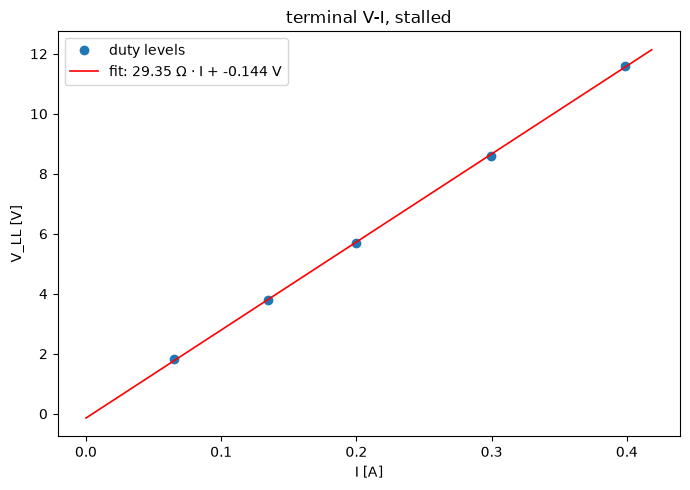

In [6]:
i_pts = np.array([r["i"] for r in rows])
v_pts = np.array([r["v_ll"] for r in rows])
(slope, intercept), cov = np.polyfit(i_pts, v_pts, 1, cov=True)
slope_sd = float(np.sqrt(cov[0, 0]))
resid = v_pts - (slope * i_pts + intercept)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(i_pts, v_pts, "o", label="duty levels")
xs = np.linspace(0, i_pts.max() * 1.05, 50)
ax.plot(xs, slope * xs + intercept, "r-", lw=1.2,
        label=f"fit: {slope:.2f} Ω · I + {intercept:.3f} V")
ax.set_xlabel("I [A]")
ax.set_ylabel("V_LL [V]")
ax.legend()
ax.set_title("terminal V-I, stalled")
fig.tight_layout()

print("=" * 62)
print("GM6208-150T terminal resistance — stalled V-I fit")
print("=" * 62)
print(f"levels in fit        : {len(rows)}")
print(f"R_terminal (slope)   : {slope:.2f} Ω  (fit sd {slope_sd:.2f})")
print(f"intercept            : {intercept * 1e3:+.0f} mV")
print(f"residual rms         : {np.sqrt((resid ** 2).mean()) * 1e3:.0f} mV")
print(f"product page         : 32 Ω ±5% (terminal)")
print(f"model r_ohm (phase)  : {slope / 2.0:.2f} Ω   <- MotorParams.r_ohm")
print("=" * 62)

## Caveats

- **Low-side shunts + asynchronous sampling** make the PWM'd leg under-read
  by ≈ `(1−duty)`; the tied-low leg is the true-current reference. The same
  effect exists in the firmware's protection reads — the SIL current-sense
  model does not reproduce it (backlogged), and PWM-synchronized (injected)
  ADC sampling is the eventual firmware fix.
- vsense samples a PWM-switched node: only segment means are meaningful.
- The mild R rise with current (few %) is copper heating; the up/down
  staircase bounds it via the repeated-level split.
- Winding resistance is angle-independent; stall creep only moves which pair
  conducts, handled per segment.